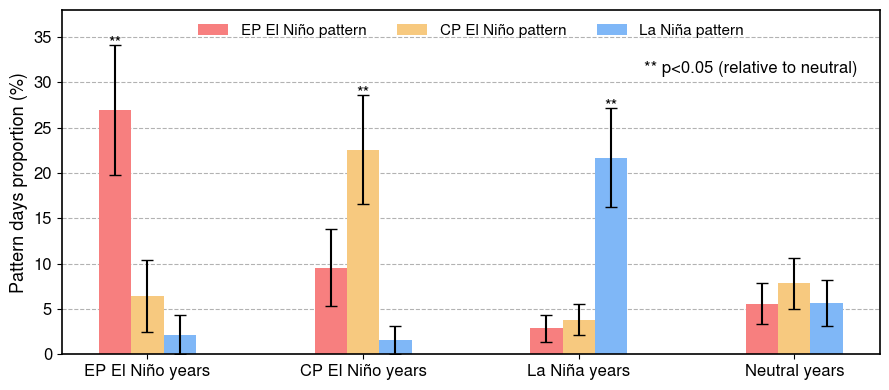

In [18]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams

# ======================
# 样式
# ======================
# mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Arial',
    'Nimbus Sans',
    'Liberation Sans',
    'DejaVu Sans'
]
rcParams['axes.linewidth'] = 1.2
rcParams['xtick.direction'] = 'out'
rcParams['ytick.direction'] = 'out'

# ======================
# 数据
# ======================
labels = ['EP El Niño years', 'CP El Niño years', 'La Niña years', 'Neutral years']

# min_duration = 10, based on comp. pattern
# 更新后的 EP (Eastern Pacific) 模式数据
ep_pattern = np.array([26.9421, 9.56316, 2.855, 5.59441])
# 更新后的 CP (Central Pacific) 模式数据
cp_pattern = np.array([6.44628, 22.5502, 3.83171, 7.81945])
# 更新后的 LaNina 模式数据
ln_pattern = np.array([2.14876, 1.53483, 21.713, 5.65798])

# 更新后的误差 (Error) 数据
ep_err = np.array([7.16963, 4.28242, 1.50075, 2.22065])
cp_err = np.array([4.00123, 6.01314, 1.67629, 2.84081])
ln_err = np.array([2.14876, 1.53483, 5.47419, 2.56926])

color_ep = (247/255, 127/255, 127/255)
color_cp = (247/255, 201/255, 127/255)
color_ln = (127/255, 183/255, 247/255)

# ======================
# 绘图
# ======================
x = np.arange(len(labels))
width = 0.15

fig, ax = plt.subplots(figsize=(9, 4))

rects1 = ax.bar(x - width, ep_pattern, width, yerr=ep_err,
                label='EP El Niño pattern', color=color_ep, capsize=4, edgecolor='none')
rects2 = ax.bar(x, cp_pattern, width, yerr=cp_err,
                label='CP El Niño pattern', color=color_cp, capsize=4, edgecolor='none')
rects3 = ax.bar(x + width, ln_pattern, width, yerr=ln_err,
                label='La Niña pattern', color=color_ln, capsize=4, edgecolor='none')

ax.set_ylabel('Pattern days proportion (%)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks(np.arange(0, 38, 5))
ax.set_ylim(0, 38)
ax.tick_params(axis='y', labelsize=12)
# ax.legend(fontsize=11, frameon=False, loc='upper right', bbox_to_anchor=(0.96, 0.93) )
ax.legend(fontsize=11, frameon=False, loc='upper center', ncol=3) 

# 添加"**"标注
ax.text(x[0] - width, ep_pattern[0]+ep_err[0]+0.25, "**", fontsize=12, ha='center', va='center')
ax.text(x[1], cp_pattern[1]+cp_err[1]+0.25, "**", fontsize=12, ha='center', va='center')
ax.text(x[2] + width, ln_pattern[2]+ln_err[2]+0.25, "**", fontsize=12, ha='center', va='center')

# 在图例正下方添加 "** p<0.05" 说明
ax.text(2.8, 31.5, "** p<0.05 (relative to neutral)", fontsize=12, ha='center', va='center')

# 灰色虚线参考线
ax.yaxis.grid(True, linestyle='--', linewidth=0.8, color='gray', alpha=0.6)
ax.set_axisbelow(True)

# # ======================
# # 显著性标注函数
# # ======================
# def significance_bar(ax, x1, x2, y, h, text):
#     """在x1和x2之间画显著性标注"""
#     ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
#     ax.text((x1 + x2) * 0.5, y + h + 0.3, text, ha='center', va='bottom', fontsize=10)
# # 添加显著性标注
# # 组1: EP vs CP
# significance_bar(ax, x[0] - width, x[0], max(ep_pattern[0]+ep_err[0], cp_pattern[0]+cp_err[0]) + 1, 0.5, "p<0.05")
# # 组2: CP vs LaNina
# significance_bar(ax, x[1], x[1] - width, max(cp_pattern[1]+cp_err[1], ln_pattern[1]+ln_err[1]) + 1, 0.5, "p<0.1")
# # 组3: LaNina vs EP
# significance_bar(ax, x[2] + width, x[2], max(ln_pattern[2]+ln_err[2], ep_pattern[2]+ep_err[2]) + 1, 0.5, "p<0.05")

plt.tight_layout()
plt.savefig('patterndays_prob.pdf')
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# 打开 NetCDF
ds_inEPElNino = xr.open_dataset("patterndays_duration_inEPElNino.nc")
ds_inCPElNino = xr.open_dataset("patterndays_duration_inCPElNino.nc")
ds_inLaNina = xr.open_dataset("patterndays_duration_inLaNina.nc")
ds_inNeutral = xr.open_dataset("patterndays_duration_inNeutral.nc")

# 对第二维平均
data_mean_inEPElNino = ds_inEPElNino['index_event'].mean(axis=1)  # shape -> (3, 121)
data_mean_inCPElNino = ds_inCPElNino['index_event'].mean(axis=1)  # shape -> (3, 121)
data_mean_inLaNina = ds_inLaNina['index_event'].mean(axis=1)  # shape -> (3, 121)
data_mean_inNeutral = ds_inNeutral['index_event'].mean(axis=1)  # shape -> (3, 121)

# 重新提取相应pattern在不同年份并组合到一起
EPElNino_pattern = np.stack([data_mean_inEPElNino[0, :], data_mean_inCPElNino[0, :], data_mean_inLaNina[0, :], data_mean_inNeutral[0, :]], axis=0)
CPElNino_pattern = np.stack([data_mean_inEPElNino[1, :], data_mean_inCPElNino[1, :], data_mean_inLaNina[1, :], data_mean_inNeutral[1, :]], axis=0)
LaNina_pattern = np.stack([data_mean_inEPElNino[2, :], data_mean_inCPElNino[2, :], data_mean_inLaNina[2, :], data_mean_inNeutral[2, :]], axis=0)

# 提取前30个指数画图
EPElNino_pattern_plot = EPElNino_pattern[:, :15]
CPElNino_pattern_plot = CPElNino_pattern[:, :15]
LaNina_pattern_plot = LaNina_pattern[:, :15]


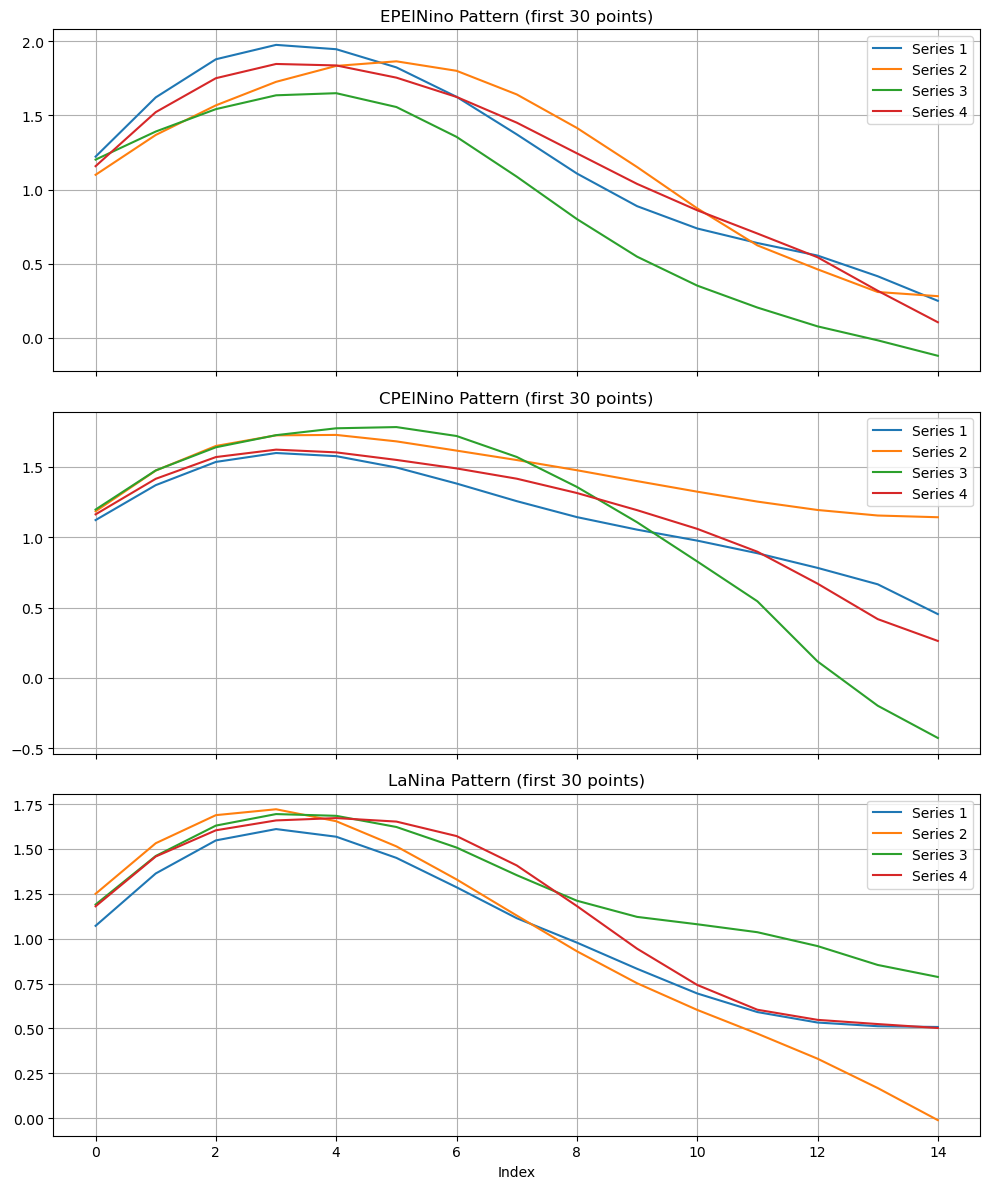

In [2]:
x = np.arange(EPElNino_pattern_plot.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 第1个子图：EPElNino
axes[0].plot(x, EPElNino_pattern_plot.T)  # 注意要转置为 (30,4)
axes[0].set_title('EPElNino Pattern (first 30 points)')
axes[0].grid(True)
axes[0].legend([f'Series {i+1}' for i in range(EPElNino_pattern_plot.shape[0])])

# 第2个子图：CPElNino
axes[1].plot(x, CPElNino_pattern_plot.T)
axes[1].set_title('CPElNino Pattern (first 30 points)')
axes[1].grid(True)
axes[1].legend([f'Series {i+1}' for i in range(CPElNino_pattern_plot.shape[0])])

# 第3个子图：LaNina
axes[2].plot(x, LaNina_pattern_plot.T)
axes[2].set_title('LaNina Pattern (first 30 points)')
axes[2].grid(True)
axes[2].legend([f'Series {i+1}' for i in range(LaNina_pattern_plot.shape[0])])

axes[2].set_xlabel('Index')

plt.tight_layout()
plt.show()

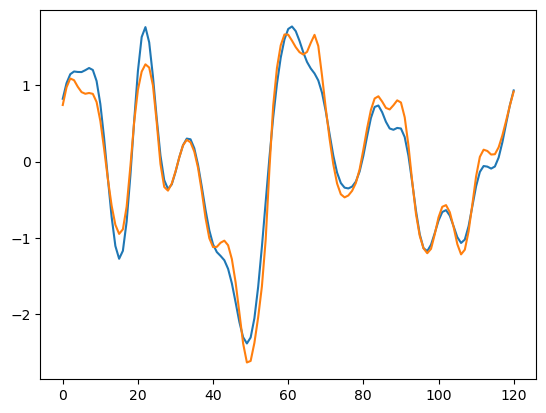

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# 打开 NetCDF
proj = xr.open_dataset("/g/data/m35/ls3248/ENSO_synop/cluster_proj/pattern_index.nc")
cor = xr.open_dataset("/g/data/m35/ls3248/ENSO_synop/cluster_based/pattern_index.nc")

# 
proj_data = proj['proj_EPElNino']
cor_data = cor['p_cor_EPElNino']

def normalize_sequence(sequence):
    mean = np.mean(sequence)
    std = np.std(sequence)
    return (sequence - mean) / std

plt.plot(proj_data[15,:], label='Proj')
plt.plot(normalize_sequence(cor_data[15,:]), label='Cor')


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# 打开 NetCDF
ds_inEPElNino = xr.open_dataset("peak_NaN/patterndays_duration_inEPElNino.nc")
ds_inCPElNino = xr.open_dataset("peak_NaN/patterndays_duration_inCPElNino.nc")
ds_inLaNina = xr.open_dataset("peak_NaN/patterndays_duration_inLaNina.nc")
ds_inNeutral = xr.open_dataset("peak_NaN/patterndays_duration_inNeutral.nc")

# 提取数组
data_inEPElNino = ds_inEPElNino['index_event']
data_inCPElNino = ds_inCPElNino['index_event']
data_inLaNina = ds_inLaNina['index_event']
data_inNeutral = ds_inNeutral['index_event']

# 重新提取相应pattern在不同年份并组合到一起
EPElNino_pattern = np.stack([data_inEPElNino[0, :, :], data_inCPElNino[0, :, :], data_inLaNina[0, :, :], data_inNeutral[0, :, :]], axis=0)
CPElNino_pattern = np.stack([data_inEPElNino[1, :, :], data_inCPElNino[1, :, :], data_inLaNina[1, :, :], data_inNeutral[1, :, :]], axis=0)
LaNina_pattern = np.stack([data_inEPElNino[2, :, :], data_inCPElNino[2, :, :], data_inLaNina[2, :, :], data_inNeutral[2, :, :]], axis=0)

/scratch/m35/ls3248/tmp/ipykernel_186279/2025266045.py:32: RuntimeWarning: Mean of empty slice
  composite_events[p, :] = np.nanmean(aligned_events, axis=0)


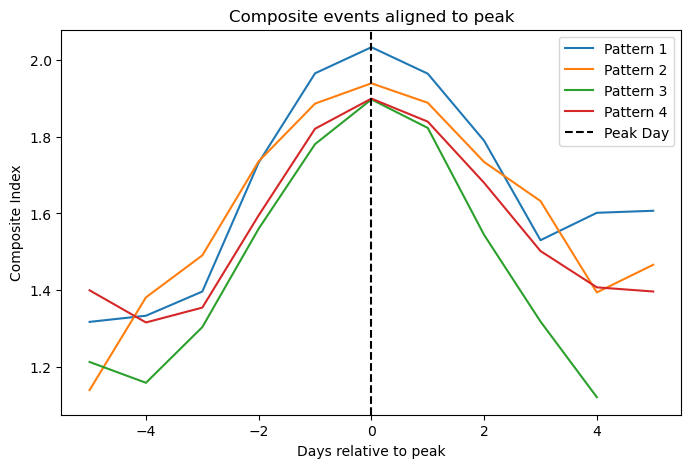

In [30]:
pattern_events = EPElNino_pattern  # 选择EP El Nino模式

n_patterns, n_events, window_len = pattern_events.shape
peak_center = window_len // 2  # 121天的中心索引，这里先用中间
lag = 5  # 前后15天

# 输出：合成序列
composite_events = np.full((n_patterns, 2*lag+1), np.nan)

for p in range(n_patterns):
    aligned_events = []
    for e in range(n_events):
        event = pattern_events[p, e, :]
        if np.all(np.isnan(event)):
            continue  # 全NaN跳过
        # 找峰值索引（忽略NaN）
        peak_idx = np.nanargmax(event)
        # 取相对峰值前后15天
        start = peak_idx - lag
        end = peak_idx + lag + 1  # +1 因为切片不包括end
        # 生成长度2*lag+1的窗口
        aligned = np.full(2*lag+1, np.nan)
        # 计算复制区间在原事件中的有效范围
        copy_start = max(0, start)
        copy_end = min(window_len, end)
        aligned_start = copy_start - start  # 对齐到aligned数组的起始索引
        aligned_end = aligned_start + (copy_end - copy_start)
        aligned[aligned_start:aligned_end] = event[copy_start:copy_end]
        aligned_events.append(aligned)
    # 求平均忽略NaN
    if aligned_events:
        composite_events[p, :] = np.nanmean(aligned_events, axis=0)

# 绘图
days = np.arange(-lag, lag+1)
plt.figure(figsize=(8,5))
for p in range(n_patterns):
    plt.plot(days, composite_events[p, :], label=f'Pattern {p+1}')
plt.axvline(0, color='k', linestyle='--', label='Peak Day')
plt.xlabel('Days relative to peak')
plt.ylabel('Composite Index')
plt.title('Composite events aligned to peak')
plt.legend()
plt.show()


/scratch/m35/ls3248/tmp/ipykernel_186279/1308717876.py:33: RuntimeWarning: Mean of empty slice
  composite_events[p, :] = np.nanmean(aligned_events, axis=0)


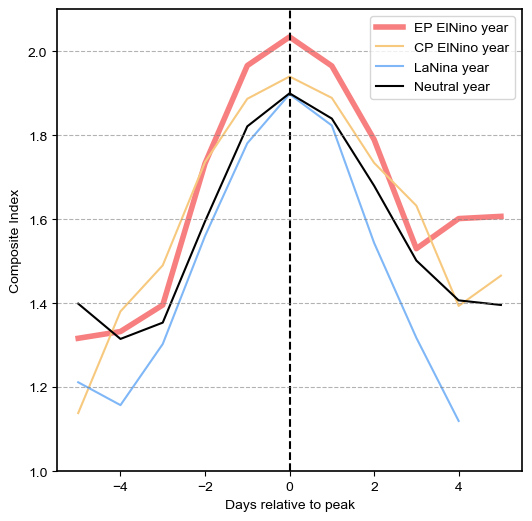

In [84]:
from scipy import stats

pattern_events = EPElNino_pattern  # 选择EP El Nino模式

n_patterns, n_events, window_len = pattern_events.shape
lag = 5

composite_events = np.full((n_patterns, 2*lag+1), np.nan)
sample_counts = np.zeros((n_patterns, 2*lag+1), dtype=int)
p_values_diff = np.ones(2*lag+1)  # Pattern1 vs others

aligned_events_all = []

# 先对每个 pattern 对齐事件
for p in range(n_patterns):
    aligned_events = []
    for e in range(n_events):
        event = pattern_events[p, e, :]
        if np.all(np.isnan(event)):
            continue
        peak_idx = np.nanargmax(event)
        start = peak_idx - lag
        end = peak_idx + lag + 1
        aligned = np.full(2*lag+1, np.nan)
        copy_start = max(0, start)
        copy_end = min(window_len, end)
        aligned_start = copy_start - start
        aligned_end = aligned_start + (copy_end - copy_start)
        aligned[aligned_start:aligned_end] = event[copy_start:copy_end]
        aligned_events.append(aligned)
    if aligned_events:
        aligned_events = np.array(aligned_events)
        composite_events[p, :] = np.nanmean(aligned_events, axis=0)
        sample_counts[p, :] = np.sum(~np.isnan(aligned_events), axis=0)
    aligned_events_all.append(aligned_events)

# PatternX 与 neutral 显著性检测
for i in range(2*lag+1):
    values1 = aligned_events_all[0][:, i]  # Pattern
    values3 = aligned_events_all[3][:, i]  # neutral
    # 去掉 NaN
    values1 = values1[~np.isnan(values1)]
    values3 = values3[~np.isnan(values3)]
    if len(values1) > 1 and len(values3) > 1:
        _, p_val = stats.ttest_ind(values1, values3, equal_var=False)  # Welch t-test
        p_values_diff[i] = p_val

# 绘图
days = np.arange(-lag, lag+1)
plt.figure(figsize=(6,6))
color_ep = (247/255, 127/255, 127/255)
color_cp = (247/255, 201/255, 127/255)
color_ln = (127/255, 183/255, 247/255)
colors = [color_ep, color_cp, color_ln, 'black']
linewidths = [4, 1.5, 1.5, 1.5]  # 对应每条曲线的粗细
labels = ['EP ElNino year', 'CP ElNino year', 'LaNina year', 'Neutral year']
for p in range(n_patterns):
    plt.plot(days, composite_events[p, :], 
             label=labels[p], 
             color=colors[p], 
             linewidth=linewidths[p])

plt.ylim(1, 2.1)
plt.axvline(0, color='k', linestyle='--')
for yline in [1.2,1.4,1.6,1.8,2]:
    plt.axhline(y=yline, linestyle='--', linewidth=0.8, color='gray', alpha=0.6)
plt.xlabel('Days relative to peak')
plt.ylabel('Composite Index')
plt.legend()
plt.show()


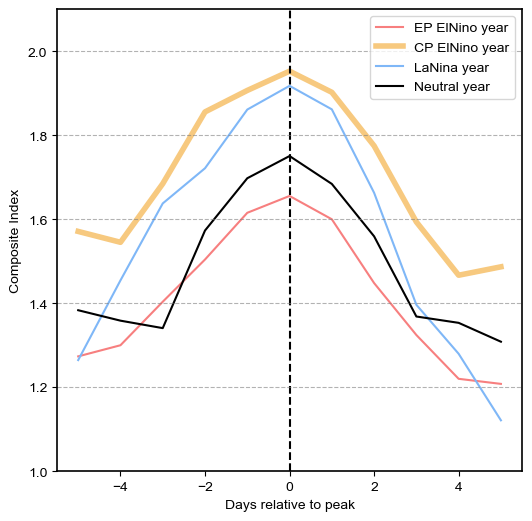

In [85]:
from scipy import stats

pattern_events = CPElNino_pattern  # 选择EP El Nino模式

n_patterns, n_events, window_len = pattern_events.shape
lag = 5

composite_events = np.full((n_patterns, 2*lag+1), np.nan)
sample_counts = np.zeros((n_patterns, 2*lag+1), dtype=int)
p_values_diff = np.ones(2*lag+1)  # Pattern1 vs others

aligned_events_all = []

# 先对每个 pattern 对齐事件
for p in range(n_patterns):
    aligned_events = []
    for e in range(n_events):
        event = pattern_events[p, e, :]
        if np.all(np.isnan(event)):
            continue
        peak_idx = np.nanargmax(event)
        start = peak_idx - lag
        end = peak_idx + lag + 1
        aligned = np.full(2*lag+1, np.nan)
        copy_start = max(0, start)
        copy_end = min(window_len, end)
        aligned_start = copy_start - start
        aligned_end = aligned_start + (copy_end - copy_start)
        aligned[aligned_start:aligned_end] = event[copy_start:copy_end]
        aligned_events.append(aligned)
    if aligned_events:
        aligned_events = np.array(aligned_events)
        composite_events[p, :] = np.nanmean(aligned_events, axis=0)
        sample_counts[p, :] = np.sum(~np.isnan(aligned_events), axis=0)
    aligned_events_all.append(aligned_events)

# PatternX 与 neutral 显著性检测
for i in range(2*lag+1):
    values1 = aligned_events_all[0][:, i]  # Pattern
    values3 = aligned_events_all[3][:, i]  # neutral
    # 去掉 NaN
    values1 = values1[~np.isnan(values1)]
    values3 = values3[~np.isnan(values3)]
    if len(values1) > 1 and len(values3) > 1:
        _, p_val = stats.ttest_ind(values1, values3, equal_var=False)  # Welch t-test
        p_values_diff[i] = p_val

# 绘图
days = np.arange(-lag, lag+1)
plt.figure(figsize=(6,6))
color_ep = (247/255, 127/255, 127/255)
color_cp = (247/255, 201/255, 127/255)
color_ln = (127/255, 183/255, 247/255)
colors = [color_ep, color_cp, color_ln, 'black']
linewidths = [1.5, 4, 1.5, 1.5]  # 对应每条曲线的粗细
labels = ['EP ElNino year', 'CP ElNino year', 'LaNina year', 'Neutral year']
for p in range(n_patterns):
    plt.plot(days, composite_events[p, :], 
             label=labels[p], 
             color=colors[p], 
             linewidth=linewidths[p])

plt.ylim(1, 2.1)
plt.axvline(0, color='k', linestyle='--')
for yline in [1.2,1.4,1.6,1.8,2]:
    plt.axhline(y=yline, linestyle='--', linewidth=0.8, color='gray', alpha=0.6)
plt.xlabel('Days relative to peak')
plt.ylabel('Composite Index')
plt.legend()
plt.show()


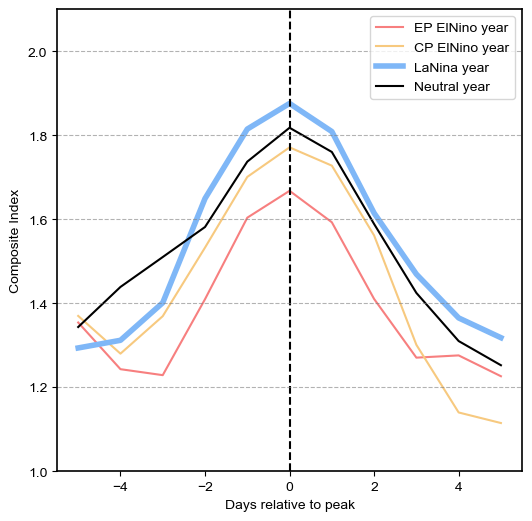

In [86]:
from scipy import stats

pattern_events = LaNina_pattern  

n_patterns, n_events, window_len = pattern_events.shape
lag = 5

composite_events = np.full((n_patterns, 2*lag+1), np.nan)
sample_counts = np.zeros((n_patterns, 2*lag+1), dtype=int)
p_values_diff = np.ones(2*lag+1)  # Pattern1 vs others

aligned_events_all = []

# 先对每个 pattern 对齐事件
for p in range(n_patterns):
    aligned_events = []
    for e in range(n_events):
        event = pattern_events[p, e, :]
        if np.all(np.isnan(event)):
            continue
        peak_idx = np.nanargmax(event)
        start = peak_idx - lag
        end = peak_idx + lag + 1
        aligned = np.full(2*lag+1, np.nan)
        copy_start = max(0, start)
        copy_end = min(window_len, end)
        aligned_start = copy_start - start
        aligned_end = aligned_start + (copy_end - copy_start)
        aligned[aligned_start:aligned_end] = event[copy_start:copy_end]
        aligned_events.append(aligned)
    if aligned_events:
        aligned_events = np.array(aligned_events)
        composite_events[p, :] = np.nanmean(aligned_events, axis=0)
        sample_counts[p, :] = np.sum(~np.isnan(aligned_events), axis=0)
    aligned_events_all.append(aligned_events)

# PatternX 与 neutral 显著性检测
for i in range(2*lag+1):
    values1 = aligned_events_all[0][:, i]  # Pattern
    values3 = aligned_events_all[3][:, i]  # neutral
    # 去掉 NaN
    values1 = values1[~np.isnan(values1)]
    values3 = values3[~np.isnan(values3)]
    if len(values1) > 1 and len(values3) > 1:
        _, p_val = stats.ttest_ind(values1, values3, equal_var=False)  # Welch t-test
        p_values_diff[i] = p_val

# 绘图
days = np.arange(-lag, lag+1)
plt.figure(figsize=(6,6))
color_ep = (247/255, 127/255, 127/255)
color_cp = (247/255, 201/255, 127/255)
color_ln = (127/255, 183/255, 247/255)
colors = [color_ep, color_cp, color_ln, 'black']
linewidths = [1.5, 1.5, 4, 1.5]  # 对应每条曲线的粗细
labels = ['EP ElNino year', 'CP ElNino year', 'LaNina year', 'Neutral year']
for p in range(n_patterns):
    plt.plot(days, composite_events[p, :], 
             label=labels[p], 
             color=colors[p], 
             linewidth=linewidths[p])

plt.ylim(1, 2.1)
plt.axvline(0, color='k', linestyle='--')
for yline in [1.2,1.4,1.6,1.8,2]:
    plt.axhline(y=yline, linestyle='--', linewidth=0.8, color='gray', alpha=0.6)
plt.xlabel('Days relative to peak')
plt.ylabel('Composite Index')
plt.legend()
plt.show()
